## Кратко в предыдущих сериях

Что советуем перед семинаром освежить в памяти из курса статистики:

* Описательные статистики: среднее, частота абсолютная и относительная, их поиск с помощью пакета `numpy`
* Генеральная совокупность, выборка
* Случайные величины, независимость случайных величин, их распределение
* Метод Монте-Карло
* Матожидание и дисперсия
* Точечные и интервальные оценки
* Оценки параметров среднего и пропорции

# Тема 1. Интро.

## 0. Цель и задачи

**Цель** — научиться видеть статистические заблуждения на практике и не попадаться на них

**Задачи:**
- вспомнить статистику (пункты выше)
- познакомиться со статистическими парадоксами
- научиться моделировать некоторые из них
- научиться видеть подвох на данных и не делать некорректные выводы

## 1. Предисловие

### 1.1 Ценность этого семинара

Ценность этого семинара в том, чтобы показать, что аналитика — это не просто про подсчет циферок, изображение их на графиках и тривиальные выводы. Это нечто более сложное и творческое. Не всегда выводы, которые кажутся очевидно правдивыми, таковыми являются. Мы рассмотрим несколько примеров и в этом убедимся.

## 2. Статистические парадоксы

### 2.1. Парадокс Симпсона

На круговой диаграме ниже представлены проценты прохождения в Калифорнийский унивеситет Berkeley при поступлении в 1976 году. В связи с этим на Berkeley был подан судебный иск за половую дискриминацию.

**Что мы видим?** — девушки значительно реже проходят отбор в школу, чем юноши: 30% против 46%.


![Simpson paradox head.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/Simpson%20paradox%20head.png)

![Simpson paradox values.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/Simpson%20paradox%20values.png)

### Вопрос в зал: Есть ли дискриминация и почему? Что же на самом деле происходит?

**Продемонстрируем парадокс в действии:** упростим ситуацию до 2 факультетов: "легкий" и "сложный". Пусть девушки больше стремятся пройти на сложный факультет, но при этом их чаще берут и на сложный, и на легкий. Подберем так данные, чтобы в итоге получилось, что по сумме девушек брали реже, чем юношей.

In [1]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import seaborn as sns
sns.set(font_scale=1, palette='Set2')
sns.set_style('whitegrid')

In [2]:
simpson_df = pd.DataFrame(data={
    'gender': ['male', 'female'],
    'applied_cnt_easy': [2_000, 500],
    'admitted_conversion_easy': [0.7, 0.8],
    'applied_cnt_hard': [500, 2_000],
    'admitted_conversion_hard': [0.4, 0.5],
    'applied_cnt_overall': [2_500, 2_500],
    'admitted_conversion_overall': [1_600 / 2_500, 1_400 / 2_500]
})
s = simpson_df.style

s.set_table_styles([  # create internal CSS classes
    {'selector': '.true', 'props': 'background-color: #e6ffe6;'},
    {'selector': '.false', 'props': 'background-color: #ffe6e6;'},
], overwrite=False)
cell_color = pd.DataFrame([['false', 'false', 'true'],
                           ['true', 'true', 'false']],
                          index=simpson_df.index,
                          columns=simpson_df.columns[[2, 4, 6]])
s.set_td_classes(cell_color)
s

,gender,applied_cnt_easy,admitted_conversion_easy,applied_cnt_hard,admitted_conversion_hard,applied_cnt_overall,admitted_conversion_overall
0,male,2000,0.700000,500,0.400000,2500,0.640000
1,female,500,0.800000,2000,0.500000,2500,0.560000


Визуализируем это в виде pie-диаграмм

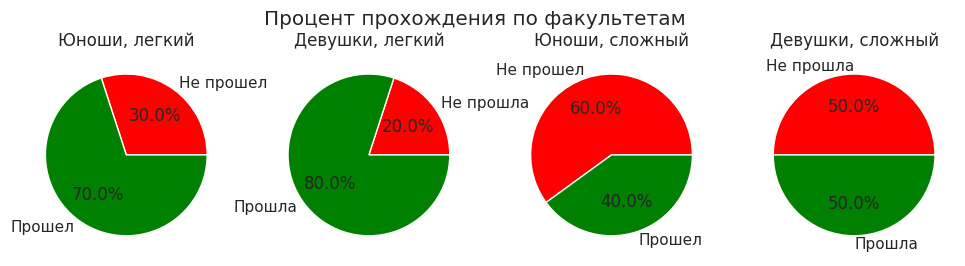

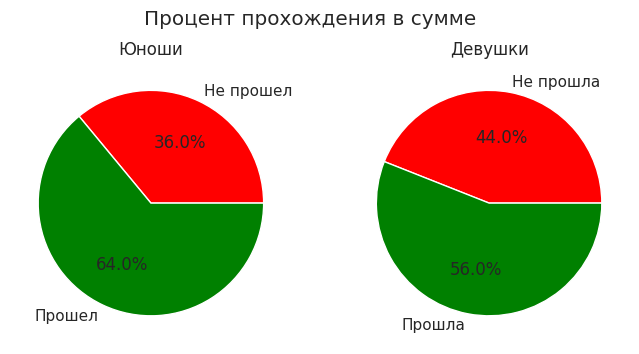

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].pie([simpson_df.loc[0, 'applied_cnt_easy'] * (1 - simpson_df.loc[0, 'admitted_conversion_easy']),
         simpson_df.loc[0, 'applied_cnt_easy'] * simpson_df.loc[0, 'admitted_conversion_easy']],
       colors = ['red', 'green'], labels=['Не прошел', 'Прошел'], autopct='%1.1f%%')
axes[0].set_title('Юноши, легкий')
axes[1].pie([simpson_df.loc[1, 'applied_cnt_easy'] * (1 - simpson_df.loc[1, 'admitted_conversion_easy']),
         simpson_df.loc[1, 'applied_cnt_easy'] * simpson_df.loc[1, 'admitted_conversion_easy']],
       colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[1].set_title('Девушки, легкий')

axes[2].pie([simpson_df.loc[0, 'applied_cnt_hard'] * (1 - simpson_df.loc[0, 'admitted_conversion_hard']),
         simpson_df.loc[0, 'applied_cnt_hard'] * simpson_df.loc[0, 'admitted_conversion_hard']],
       colors = ['red', 'green'], labels=['Не прошел', 'Прошел'], autopct='%1.1f%%')
axes[2].set_title('Юноши, сложный')
axes[3].pie([simpson_df.loc[1, 'applied_cnt_hard'] * (1 - simpson_df.loc[1, 'admitted_conversion_hard']),
         simpson_df.loc[1, 'applied_cnt_hard'] * simpson_df.loc[1, 'admitted_conversion_hard']],
       colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[3].set_title('Девушки, сложный')
plt.suptitle('Процент прохождения по факультетам')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].pie(
    [simpson_df.loc[0, 'applied_cnt_overall'] * (1 - simpson_df.loc[0, 'admitted_conversion_overall']),
     simpson_df.loc[0, 'applied_cnt_overall'] * simpson_df.loc[0, 'admitted_conversion_overall']],
     colors = ['red', 'green'], labels=['Не прошел', 'Прошел'], autopct='%1.1f%%')
axes[0].set_title('Юноши')
axes[1].pie(
    [simpson_df.loc[1, 'applied_cnt_overall'] * (1 - simpson_df.loc[1, 'admitted_conversion_overall']),
     simpson_df.loc[1, 'applied_cnt_overall'] * simpson_df.loc[1, 'admitted_conversion_overall']],
     colors = ['red', 'green'], labels=['Не прошла', 'Прошла'], autopct='%1.1f%%')
axes[1].set_title('Девушки')
plt.suptitle('Процент прохождения в сумме')
plt.show()

### 2.2. Парадокс Монти-Холла

![Monti hall paradox.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/Goats%20and%20car.png)


> Представьте, что вы стали участником игры, в которой вам нужно выбрать одну из трёх дверей. За одной из дверей находится автомобиль, за двумя другими дверями — козы. Вы выбираете одну из дверей, например, номер 1, после этого ведущий, который знает, где находится автомобиль, а где — козы, открывает одну из оставшихся дверей, например, номер 3, за которой находится коза. После этого он спрашивает вас — не желаете ли вы изменить свой выбор и выбрать дверь номер 2?


### Вопрос в зал: Примете ли вы предложение ведущего или не измените свой выбор?


На первый взгляд кажется, что без разницы, менять дверь или нет: двери осталось 2, значит, за каждой из дверью вероятность встретить автомобиль 50%. Но давайте это проверим на практике.

Вы уже знакомы с методом Монте-Карло, так давайте просимулируем игру на python! Пусть автомобиль находится за случайной дверью и игрок тоже выбирает случайную дверь. Сначала протестируем стратегию без смены двери, а потом — со сменой и сравним результаты.

### Практика: вставьте недостающие части кода

In [ ]:
def monty_hall_game(change=False, n_iters=10_000):
    '''
    Функция, симулирующая игру Монти-Холла с помощью метода Монте-Карло

    Параметры:
        - change: bool, default=False —— параметр, отвечающий за перемену / не перемену двери
        - n_iters: int, default=10_000 —— кол-во итераций метода Монте-Карло

    Возвращает:
        - results: list[bool] —— массив результатов симуляций метода Монте-Карло.
                                 True — игрок выиграл автомобиль, False — игрок не выиграл автомобиль

    '''
    results = []
    doors = [1, 2, 3]
    for _ in range(n_iters):

        door_auto = # напишите выбор случайной двери из 3 с помощью пакета numpy
        door_player = # напишите выбор случайной двери из 3 с помощью пакета numpy
        # двери, которые может открыть ведущий:
        doors_may_open = [door for door in doors if (door != door_auto and door != door_player)]
        door_opened = # напишите выбор случайной двери из тех, которые может открыть ведущий
        if change:
            new_door_player = # напишите, какую теперь выбирает дверь игрок
            door_player = new_door_player

        results.append(int(door_player == door_auto))

    return results

results_change = monty_hall_game(change=True)
results_not_change = monty_hall_game(change=False)

print(f'результат, когда меняем дверь: {np.round(<выведете процент успеха игрока>, 1)}%')
print(f'результат, когда не меняем дверь: {np.round(<выведете процент успеха игрока>, 1)}%')

**Поразительно!** В 2/3 случаев, когда мы меняем дверь, мы выигрываем, тогда как если не меняем, выигрываем только в 1/3 случаев.

Но как так? — Дело в том, что если не менять дверь, то вы выиграете с вероятностью, равной первоначальной, то есть, 1/3. При этом у вас есть 2 двери и 2 решения: менять дверь или нет, и где-то находится автомобиль (так как открыли дверь с козой). Значит, если вероятность выиграть без смены двери 1/3, то вероятность со сменой двери — 2/3!

Но почему 2/3? — Потому что исключение одной двери перенесло всю вероятность авто в ту, на которую вы можете поменять. Более формально — можно покопаться в условных вероятностях и получить требуемые 1/3 и 2/3 вероятности.

### 2.3. Ошибка выжившего

> В одну американскую больницу направляли всех пострадавших в результате несчастных случаев в городе. Но больше всего в больницу попадало водителей и пассажиров, пострадавших в ДТП. Чтобы уменьшить их количество, городские власти сделали обязательным пользование ремнями безопасности. Водители и пассажиры стали пристегиваться ремнями. После этого число ДТП осталось неизменным, но вот число пострадавших в них людей, которые поступали в больницу, даже увеличилось. Вопрос: Почему?

На первый взгляд зависимость такая: начали пристегиваться $\rightarrow$ стало больше пострадавших $\rightarrow$ ремни неэффективны

### Вопрос в зал: что произошло на самом деле?

### 2.4. Ошибка базовой вероятности

#### 2.4.1. Пререквезит: условная вероятность

- ***Вероятность события $A$, если известно, что произошло событие $B$***:  
  $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)}, \, \mathsf{P}(B) > 0.$$  
  *Пример*: вероятность, что выпадет 6, если известно, что выпало четное число.  
  
  
- **Независимость событий**: события $A$ и $B$ ***независимы***, если $\mathsf{P}(A \cap B) = \mathsf{P}(A) \cdot \mathsf{P}(B)$.  
  *Пример*: вероятность, что выпадет 6, если известно, что в прошлый раз выпало 3.  
  
> **Замечание:** независимость еще можно определить как $\mathsf{P}(A|B) = \mathsf{P}(A)$, если $P(B) \neq 0$.
  
- **Задачка на условные вероятности**:  

**Задача: Игральные кости**  
1. Бросают игральную кость. Какова вероятность того, что выпало число 5?  

    *Ответ:*  вероятность того, что выпало число 5, равна $\frac{1}{6}$.

2. Бросают две игральные кости. Известно, что сумма выпавших очков равна 8.

    *Вопрос:*
    - Какова вероятность того, что на первой кости выпало число 5?  

    *Решение:*  

    1. Пространство элементарных событий:  
    Всего возможных пар исходов при броске двух костей — $6 \times 6 = 36$.  

    2. Условие:  
    Рассматриваем только те исходы, где сумма очков равна 8:  
    $$(2, 6), (3, 5), (4, 4), (5, 3), (6, 2).$$  
    Таким образом, всего таких исходов 5.  

    3. Интересующее событие:  
    На первой кости выпало 5. Подходящий исход — $(5, 3)$.  

    4. Условная вероятность:  
    По формуле условной вероятности:  
    $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)}.$$  
    Вероятность события $B$ (сумма равна 8):  
    $$\mathsf{P}(B) = \frac{\text{Число подходящих исходов}}{\text{Общее число исходов}} = \frac{5}{36}.$$  
    Вероятность события $A \cap B$ (первая кость — 5, сумма — 8):  
    $$\mathsf{P}(A \cap B) = \frac{1}{36}.$$  
    Условная вероятность:  
    $$\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)} = \frac{\frac{1}{36}}{\frac{5}{36}} = \frac{1}{5}.$$  

    ---

    *Ответ:*  вероятность того, что на первой кости выпало число 5, если известно, что сумма равна 8, равна $\frac{1}{5}$.

    ---

#### 2.4.2. Пререквезит: формула Байеса и формула полной вероятности

> **Теорема (формула Байеса):** $\mathsf{P}(A|B) = \frac{\mathsf{P}(B|A)\mathsf{P}(A)}{\mathsf{P}(B)}.$

> **Доказательство:** по определению условной вероятности: $\mathsf{P}(A|B) = \frac{\mathsf{P}(A \cap B)}{\mathsf{P}(B)} = \frac{\mathsf{P}(B|A) \mathsf{P}(A)}{\mathsf{P}(B)}.$

> **Теорема (формула полной вероятности):** если $A = \sqcup A_i$, то есть, $A$ состоит из объединения непересекающихся событий $A_i$, то $\mathsf{P}(B) = \sum\mathsf{P}(B|A_i)\mathsf{P}(A_i).$

> **Доказательство:** так как $A$ состоит из объединения непересекающихся событий $A_i$, то $B =  \sum\mathsf{P}(B \cap A_i)$, а каждое $\mathsf{P}(B \cap A_i) = \mathsf{P}(B|A_i)\mathsf{P}(A_i)$ по определению условной вероятности.

> *Следствие:* $\mathsf{P}(A_j|B) = \frac{\mathsf{P}(B|A_j)\mathsf{P}(A)}{\sum\mathsf{P}(B|A_i)\mathsf{P}(A_i)}.$

---
#### 2.4.3. Ошибка базовой вероятности на примере парадокса полицейского

![Police paradox.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/Police%20paradox.png)

> - Алкотестер почти идеален:
>     - Точность при наличии алкоголя: 100% (если человек пьян, алкотестер это определит всегда)
>     - Точность при отсутствии алкоголя: 98% (если человек не пьян, алкотестер в 2% случая скажет, что он пьян)
> - Реально пьян только каждый тысячный человек
> - Полицейский проверил случайного человека и алкотестер показал, что он пьян
> - Полицейский сказал, что этот человек пьян с вероятностью 98% и взял штраф с человека

### Вопрос в зал: прав ли полицейский?


### 2.5. Парадокс друзей

> Почему твои друзья популярнее, чем ты (если ты не Кайли Дженнер)?

> Согласно данным ученых из университета Южной Калифорнии, более, чем 98% пользователей твиттера имеют меньше друзей, чем их друзья в среднем.

![Friendship paradox.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/Friendship%20paradox.png)


### Тизер к ДЗ: объяснить этот парадокс

    
Чтобы убедиться, что парадокс работает, рассмотрим на небольшой пример с графом друзей:

In [4]:
from graphviz import Graph as GVGraph
from itertools import permutations

In [5]:
np.random.seed(seed=42)

persons = ['Алиса', 'Борис', 'Виталий', 'Геннадий', 'Елена', 'Жанна', 'Зиновий', 'Илья']
# генерируем некоторую меру дружбы для каждого из компании
p_friendship = sps.beta(a=0.8, b=0.8).rvs(size=len(persons))
probs = dict(zip(persons, p_friendship))

# генерируем граф дружбы
relations = []
for pair in permutations(persons, 2):
    if pair[0] < pair[1]:
        # вероятность дружбы — среднее арифметическое мер дружбы 2 человек
        friendship = sps.bernoulli((probs[pair[0]] + probs[pair[1]]) / 2).rvs()
        if friendship == 1:
            relations.append(pair)

relations

[('Алиса', 'Геннадий'),
 ('Алиса', 'Елена'),
 ('Алиса', 'Зиновий'),
 ('Алиса', 'Илья'),
 ('Борис', 'Геннадий'),
 ('Борис', 'Зиновий'),
 ('Борис', 'Илья'),
 ('Виталий', 'Геннадий'),
 ('Геннадий', 'Елена'),
 ('Геннадий', 'Жанна'),
 ('Геннадий', 'Зиновий'),
 ('Елена', 'Илья'),
 ('Жанна', 'Илья'),
 ('Зиновий', 'Илья')]

In [6]:
class Vertex:
    """
    Класс представляет вершину графа.

    Атрибуты:
        name (str): имя вершины (уникальный идентификатор).
        neighbors (set[Vertex]): множество соседних вершин.

    Методы:
        add_neighbor(vertex): добавляет вершину в список соседей.
        degree(): возвращает количество соседей (степень вершины).
        get_neighbors(): возвращает список соседних вершин.
        get_neighbor_by_name(name): ищет соседа по имени.
    """

    def __init__(self, name):
        """
        Создает вершину с заданным именем и пустым множеством соседей.

        Args:
            name (str): имя вершины.
        """
        self.name = name
        self.neighbors = set()

    def add_neighbor(self, vertex):
        """
        Добавляет вершину vertex в список соседей текущей вершины.

        Args:
            vertex (Vertex): соседняя вершина.
        """
        self.neighbors.add(vertex)

    def degree(self):
        """
        Возвращает количество соседей (степень вершины).

        Returns:
            int: число соседей.
        """
        return len(self.neighbors)

    def get_neighbors(self):
        """
        Возвращает список соседних вершин.

        Returns:
            list[Vertex]: список соседей.
        """
        return list(self.neighbors)

    def get_neighbor_by_name(self, name):
        """
        Ищет среди соседей вершину с указанным именем.

        Args:
            name (str): имя искомой вершины.

        Returns:
            Vertex | None: вершина с заданным именем или None, если сосед не найден.
        """
        for neighbor in self.neighbors:
            if neighbor.name == name:
                return neighbor
        return None

    def __repr__(self):
        """Возвращает строковое представление вершины."""
        return f"Vertex({self.name})"


class Graph:
    """
    Класс представляет неориентированный граф.

    Атрибуты:
        vertices (dict[str, Vertex]): словарь, где ключ — имя вершины, а значение — объект Vertex.

    Методы:
        from_edge_list(edge_list): создает граф на основе списка рёбер.
        add_vertex(name): добавляет вершину по имени.
        add_edge(from_name, to_name): добавляет ребро между вершинами.
        get_vertex(name): возвращает вершину по имени.
        visualize(): строит визуализацию графа через Graphviz.
    """

    def __init__(self):
        """
        Создает пустой граф.
        """
        self.vertices = {}

    @classmethod
    def from_edge_list(cls, edge_list):
        """
        Создает граф на основе списка рёбер.

        Args:
            edge_list (list[tuple[str, str]]): список рёбер в формате (from_v, to_v).

        Returns:
            Graph: объект графа.
        """
        graph = cls()
        for from_v, to_v in edge_list:
            graph.add_edge(from_v, to_v)
        return graph

    def add_vertex(self, name):
        """
        Добавляет вершину с именем name в граф, если она ещё не существует.

        Args:
            name (str): имя вершины.

        Returns:
            Vertex: объект вершины.
        """
        if name not in self.vertices:
            self.vertices[name] = Vertex(name)
        return self.vertices[name]

    def add_edge(self, from_name, to_name):
        """
        Добавляет ребро между вершинами from_name и to_name.
        Если вершины ещё не существуют, они будут автоматически добавлены.

        Args:
            from_name (str): имя первой вершины.
            to_name (str): имя второй вершины.
        """
        from_vertex = self.add_vertex(from_name)
        to_vertex = self.add_vertex(to_name)
        from_vertex.add_neighbor(to_vertex)
        to_vertex.add_neighbor(from_vertex)

    def get_vertex(self, name):
        """
        Возвращает вершину по имени.

        Args:
            name (str): имя вершины.

        Returns:
            Vertex | None: вершина с заданным именем или None, если такой нет.
        """
        return self.vertices.get(name, None)

    def visualize(self):
        """
        Создает объект GVGraph для визуализации графа (например, через Graphviz).
        Добавляет все вершины и рёбра, исключая дублирование.

        Returns:
            GVGraph: объект для построения визуализации.
        """
        dot = GVGraph()
        added_edges = set()
        for vertex in self.vertices.values():
            dot.node(vertex.name)
            for neighbor in vertex.neighbors:
                edge = tuple(sorted((vertex.name, neighbor.name)))
                if edge not in added_edges:
                    dot.edge(vertex.name, neighbor.name)
                    added_edges.add(edge)
        return dot

    def __repr__(self):
        """Возвращает строковое представление графа."""
        return f"Graph(vertices={list(self.vertices.keys())})"

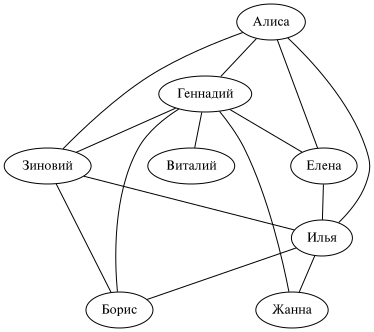

In [7]:
friends_graph = Graph.from_edge_list(relations)
friends_graph.visualize()

In [8]:
friends_graph.vertices

{'Алиса': Vertex(Алиса),
 'Геннадий': Vertex(Геннадий),
 'Елена': Vertex(Елена),
 'Зиновий': Vertex(Зиновий),
 'Илья': Vertex(Илья),
 'Борис': Vertex(Борис),
 'Виталий': Vertex(Виталий),
 'Жанна': Vertex(Жанна)}

### Практика: дополните код для подсчета друзей

In [ ]:
# создаем пустой датафрейм
cnt_friends_df = pd.DataFrame(columns=['имя', 'кол-во друзей', 'среднее кол-во друзей у друзей'])

# проходимся по людям
for person in persons:
    vertex_person = # вызовете метод, который по имени достает вершину
    cnt_person = # вызовете метод, который по вершине достает кол-во связей
    neighbours = # вызовете метод, который по вершине достает соседей
    cnt_friends_of_friend = []
    # проходимся по соседям
    for neighbour in neighbours:
        cnt_friends_of_friend.append(# вызовете метод, который по вершине соседа достает кол-во связей)

    avg_cnt_friends_of_friend = # вызовете функцию из numpy для подсчета среднего
    cnt_friends_row = pd.DataFrame(data={'имя': [person],
                                         'кол-во друзей': [cnt_person],
                                         'среднее кол-во друзей у друзей': [avg_cnt_friends_of_friend]})
    cnt_friends_df = pd.concat([cnt_friends_df, cnt_friends_row], ignore_index=True)

cnt_friends_df

In [ ]:
cnt = len(cnt_friends_df[cnt_friends_df['кол-во друзей'] > cnt_friends_df['среднее кол-во друзей у друзей']])

print(f'у {100 * np.round(1 - cnt / len(persons), 2)}% друзей меньше, чем у среднего их друга')

**Где еще можно встретиться с парадоксом дружбы:**
- *парадокс ожидания поезда:* если спросить у людей, стоящих на платформе, сколько они ждут поезд, то получится в среднем больше, чем если оценить среднее время ожидания случайного человека
- *нагрузки на сервер:* если пользователи распределены неравномерно между серверами, то средний пользователь будет себя чувствовать в среднем хуже, чем средний по всем серверам
- *предупреждение эпидемий:* при предупреждении эпидемий обычно смотрят на здоровье не случайных людей, а друзей случайных людей. Все потому, что друзья имеют в среднем больше контактов, а значит, лучше в первую очередь оградить их при наличии у них симптомов

### 3. Заключение: что за парадоксы ниже на картинках

### 3.1.
![T Data paradox.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/T%20Data%20Paradox.png)

### 3.2.
![T Data paradox2.png](https://raw.githubusercontent.com/polozovds/CU-materials/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%201%2C%20%D0%B8%D0%BD%D1%82%D1%80%D0%BE/T%20Data%20Paradox2.png)

## 4. Итоги семинара

С чем выходим с занятия:
- разобрались, почему не стоит делать выводы на средних, если мы не знаем, случайно ли были собраны группы (парадокс Симпсона)
- увидели, что стоит пересчитывать вероятность событий, опираясь на новую информацию (не путать с подглядыванием: если подглянуть, то можно преждевременно открыть дверь с козой, даже не дождавшись информации от ведущего)
- разобрались, почему не стоит делать выводы на смещенной выборке (ошибка выжившего)
- увидели, что нужно глубоко понимать разные вероятности и правильно их интерпретировать
- увидели на примере парадокс дружбы, повысили себе самооценку и поняли, как эту информацию можно использовать на практике

## 5. Полезные материалы

- [Иллюстрация с парадоксом Симпсона](https://setosa.io/simpsons/)
- [Шортс про парадокс выжившего](https://www.youtube.com/shorts/bFg1TCLRk7s)
- [Про условную вероятность (там еще в ссылках формула Байеса и формула полной вероятности)](https://ru.wikipedia.org/wiki/%D0%A3%D1%81%D0%BB%D0%BE%D0%B2%D0%BD%D0%B0%D1%8F_%D0%B2%D0%B5%D1%80%D0%BE%D1%8F%D1%82%D0%BD%D0%BE%D1%81%D1%82%D1%8C)
- [Пардокс полицейского или ошибка базового процента на вики](https://ru.wikipedia.org/wiki/%D0%9E%D1%88%D0%B8%D0%B1%D0%BA%D0%B0_%D0%B1%D0%B0%D0%B7%D0%BE%D0%B2%D0%BE%D0%B3%D0%BE_%D0%BF%D1%80%D0%BE%D1%86%D0%B5%D0%BD%D1%82%D0%B0)
- [Статья на хабре про пададокс дружбы](https://habr.com/ru/articles/383787/)
- [Статья про парадокс дружбы](https://web.archive.org/web/20141019095712/http://www-scf.usc.edu/~kooti/files/FriendParadoxRedux.pdf)